In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from astropy.io import fits
import glob, os

folder = 'fits/202605182208'   # <-- set this

files = sorted(
    glob.glob(os.path.join(folder, 'psi*.fit')),
    key=lambda f: int(os.path.basename(f).replace('psi','').replace('.fit',''))
)
print(f"Found {len(files)} frames in {folder}")

Found 1600 frames in fits/202605182208


In [12]:
frames = []
for f in files:
    with fits.open(f) as hdul:
        frames.append(hdul[0].data.astype(np.float64))
frames = np.array(frames)
print(f"Frame shape: {frames[0].shape}, total frames: {len(frames)}")

L = 15.0        # half-box in dimensionless units (ℓ)
ell_um = 0.88   # oscillator length in μm
extent = [-L*ell_um, L*ell_um, -L*ell_um, L*ell_um]

N = frames[0].shape[0]
dx_ell  = 2 * L / N
p_max   = np.pi / dx_ell          # ≈ 26.8 ℏ/ℓ
k_rec   = 7.1                     # recoil momentum ℏ/ℓ
E_rec   = 0.5 * k_rec**2
omega_r = 8.0 * E_rec             # Rabi coupling ℏω  (OMEGA_R_EREC=8)
det_grad = -0.4 * ell_um * 1e3 / 150.0   # -0.4 kHz/μm → ℏω/ℓ

# Clip px display to ±3·k_rec so the band tilt is visible
px_clip  = 8.0 * k_rec
kinx_extent = [-px_clip, px_clip, -L*ell_um, L*ell_um]

# Natural-order px axis (after fftshift) and column mask for clipping
px_natural = np.fft.fftshift(np.fft.fftfreq(N, d=dx_ell / (2*np.pi)))
px_cols    = np.where(np.abs(px_natural) <= px_clip)[0]

def load_kinx_fits(path):
    with fits.open(path) as hdul:
        data = np.fft.fftshift(hdul[0].data.astype(np.float64), axes=1)
    return data[:, px_cols]

kinx_files = sorted(
    glob.glob(os.path.join(folder, 'kinx*.fit')),
    key=lambda f: int(os.path.basename(f).replace('kinx','').replace('.fit',''))
)

if kinx_files:
    kinx_frames = np.array([load_kinx_fits(f) for f in kinx_files])
    print(f"Loaded {len(kinx_frames)} kinx frames from FITS (fftshifted, px-clipped)")
else:
    print("No kinx*.fit files — computing adiabatic dispersion analytically")
    ramp_tmp      = np.loadtxt('detuning_ramp.txt', skiprows=1)
    frame_nums_tmp = [int(os.path.basename(f).replace('psi','').replace('.fit','')) for f in files]
    px_v  = px_natural[px_cols]
    y_v   = np.linspace(-L, L, N, endpoint=False)
    px2d  = px_v[np.newaxis, :]
    y2d   = y_v[:, np.newaxis]
    hO    = omega_r / 2
    kinx_frames = []
    for fn in frame_nums_tmp:
        rv    = ramp_tmp[fn] if fn < len(ramp_tmp) else 1.0
        delta = rv * det_grad * y2d
        H1 = 0.5 * (px2d - 2*k_rec)**2 + delta
        H2 = 0.5 * px2d**2 + np.zeros_like(delta)
        H3 = 0.5 * (px2d + 2*k_rec)**2 - delta
        Hb = np.zeros(H1.shape + (3, 3))
        Hb[...,0,0]=H1; Hb[...,0,1]=hO
        Hb[...,1,0]=hO; Hb[...,1,1]=H2; Hb[...,1,2]=hO
        Hb[...,2,1]=hO; Hb[...,2,2]=H3
        kinx_frames.append(np.linalg.eigvalsh(Hb)[..., 0])
    kinx_frames = np.array(kinx_frames)
    print(f"Computed {len(kinx_frames)} analytical frames")

vmin = 0
vmax = np.percentile(frames, 99.5)
kinx_abs  = np.percentile(np.abs(kinx_frames), 98)
kinx_vmin, kinx_vmax = -kinx_abs, kinx_abs
print(f"kinx display range: {kinx_vmin:.1f} to {kinx_vmax:.1f} ℏω")

Frame shape: (256, 256), total frames: 1600
Loaded 1600 kinx frames from FITS (fftshifted, px-clipped)
kinx display range: -378.3 to 378.3 ℏω


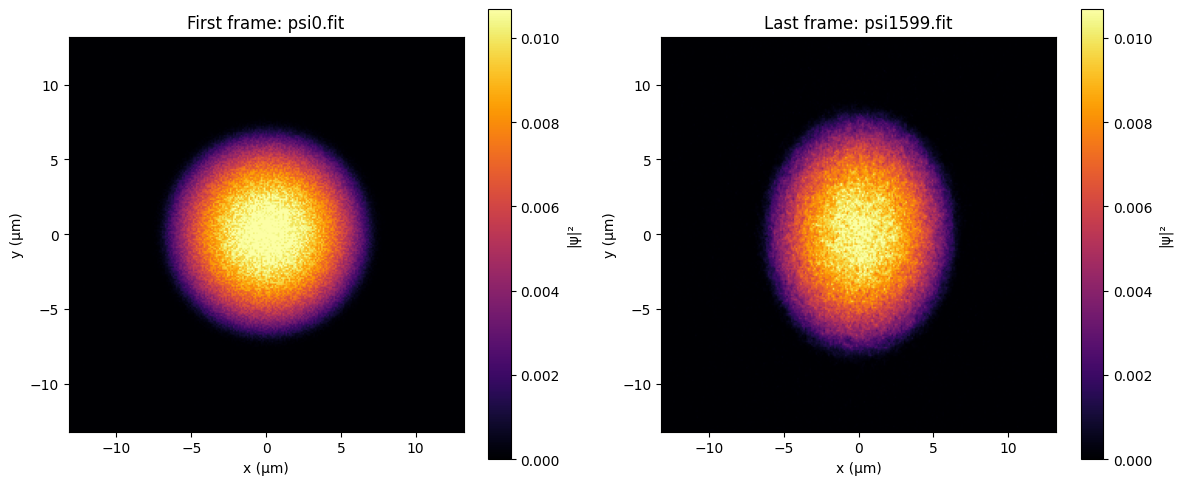

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, idx, label in zip(axes, [0, -1], ['First frame', 'Last frame']):
    im = ax.imshow(frames[idx], origin='lower', extent=extent,
                   vmin=vmin, vmax=vmax, cmap='inferno')
    ax.set_title(f"{label}: {os.path.basename(files[idx])}")
    ax.set_xlabel('x (μm)')
    ax.set_ylabel('y (μm)')
    plt.colorbar(im, ax=ax, label='|ψ|²')
plt.tight_layout()
plt.savefig('first_last.png', dpi=150, bbox_inches='tight')
plt.show()

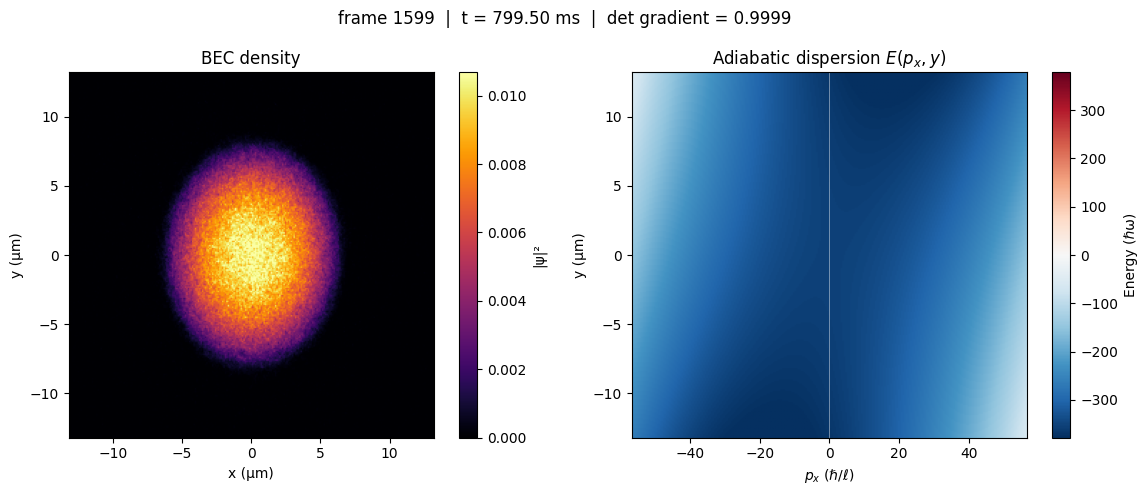

Animation saved to evolution.gif


In [14]:
DT_US           = 1.0    # μs per step
SAVE_INTERVAL_MS = 0.5   # ms between saved frames (must match SimulationData.cpp)

ramp = np.loadtxt('detuning_ramp.txt', skiprows=1)
save_interval = int(SAVE_INTERVAL_MS * 1e3 / DT_US)   # steps between frames = 500

frame_nums = [
    int(os.path.basename(f).replace('psi','').replace('.fit',''))
    for f in files
]

fig, (ax_psi, ax_kinx) = plt.subplots(1, 2, figsize=(12, 5))

im_psi = ax_psi.imshow(frames[0], origin='lower', extent=extent,
                        vmin=vmin, vmax=vmax, cmap='inferno', animated=True)
plt.colorbar(im_psi, ax=ax_psi, label='|ψ|²')
ax_psi.set_xlabel('x (μm)')
ax_psi.set_ylabel('y (μm)')
ax_psi.set_title('BEC density')

im_kinx = ax_kinx.imshow(kinx_frames[0], origin='lower', extent=kinx_extent, aspect='auto',
                          vmin=kinx_vmin, vmax=kinx_vmax, cmap='RdBu_r', animated=True)
plt.colorbar(im_kinx, ax=ax_kinx, label='Energy (ℏω)')
ax_kinx.set_xlabel('$p_x$ (ℏ/ℓ)')
ax_kinx.set_ylabel('y (μm)')
ax_kinx.set_title('Adiabatic dispersion $E(p_x, y)$')
ax_kinx.axvline(0, color='w', linewidth=0.5, alpha=0.6)

def make_title(i):
    n      = frame_nums[i]
    step   = n * save_interval
    t_ms   = step * DT_US * 1e-3          # frame → step → ms
    ramp_step = min(step, len(ramp) - 1)
    det    = ramp[ramp_step]
    return f"frame {n}  |  t = {t_ms:.2f} ms  |  det gradient = {det:.4f}"

title = fig.suptitle(make_title(0))
plt.tight_layout()

def update(i):
    im_psi.set_array(frames[i])
    im_kinx.set_array(kinx_frames[i])
    title.set_text(make_title(i))
    return im_psi, im_kinx, title

ani = animation.FuncAnimation(
    fig, update, frames=len(files), interval=150, blit=False
)
ani.save('evolution.gif', writer='pillow', fps=8)
plt.show()
print("Animation saved to evolution.gif")

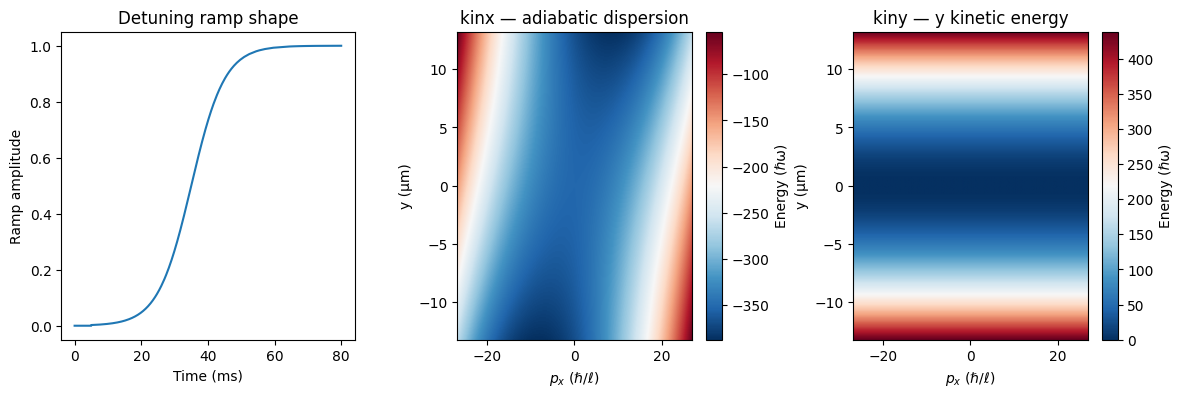

In [15]:
# ── Detuning ramp + kinx/kiny ─────────────────────────────────────────────────
DT_US   = 1.0    # must match SimulationData.cpp
k_rec   = 7.1    # recoil momentum in units of 1/ell (Rb-87 at 790 nm, ell=0.88 um)

# Detuning ramp shape (0→1 vs time)
ramp = np.loadtxt('detuning_ramp.txt', skiprows=1)
t_ms = np.arange(len(ramp)) * DT_US * 1e-3   # steps × μs → ms

# kinx: adiabatic dispersion surface, axes are (y position, px momentum)
# kiny: free y kinetic energy surface, axes are (py momentum, x position)
with fits.open('kinx.fit') as h:
    kinx = np.fft.fftshift(h[0].data.astype(np.float64), axes=1)  # px axis is FFT-ordered
with fits.open('kiny.fit') as h:
    kiny = np.fft.fftshift(h[0].data.astype(np.float64), axes=0)  # py axis is FFT-ordered

# Momentum extent: px in units of ℏ/ell, range ≈ ±π/dx
dx_ell  = 2 * L / kinx.shape[1]
p_max   = np.pi / dx_ell
p_ext   = [-p_max, p_max, -L*ell_um, L*ell_um]   # [px_min, px_max, y_min, y_max] in (ℏ/ell, μm)

fig = plt.figure(figsize=(14, 4))
gs  = fig.add_gridspec(1, 3, wspace=0.35)

# Detuning ramp
ax0 = fig.add_subplot(gs[0])
ax0.plot(t_ms, ramp)
ax0.set_xlabel('Time (ms)')
ax0.set_ylabel('Ramp amplitude')
ax0.set_title('Detuning ramp shape')
ax0.set_ylim(-0.05, 1.05)

# kinx — adiabatic energy surface in (px, y)
ax1 = fig.add_subplot(gs[1])
im1 = ax1.imshow(kinx, origin='lower', aspect='auto', extent=p_ext, cmap='RdBu_r')
ax1.set_xlabel('$p_x$ (ℏ/ℓ)')
ax1.set_ylabel('y (μm)')
ax1.set_title('kinx — adiabatic dispersion')
plt.colorbar(im1, ax=ax1, label='Energy (ℏω)')

# kiny — y kinetic energy surface
ax2 = fig.add_subplot(gs[2])
im2 = ax2.imshow(kiny, origin='lower', aspect='auto', extent=p_ext, cmap='RdBu_r')
ax2.set_xlabel('$p_x$ (ℏ/ℓ)')
ax2.set_ylabel('y (μm)')
ax2.set_title('kiny — y kinetic energy')
plt.colorbar(im2, ax=ax2, label='Energy (ℏω)')

plt.savefig('gauge_field.png', dpi=150, bbox_inches='tight')
plt.show()